In [1]:
import numpy as np
import matplotlib.pyplot as plt

Successfully loaded data from 'volume_run_data/consolidated_mbar_data.csv'.
Initial rows: 50
Dropped 30 rows due to missing values in key columns.
Calculated 'F0_per_particle'.
Calculated average and standard deviation for each group.
Generating plot...


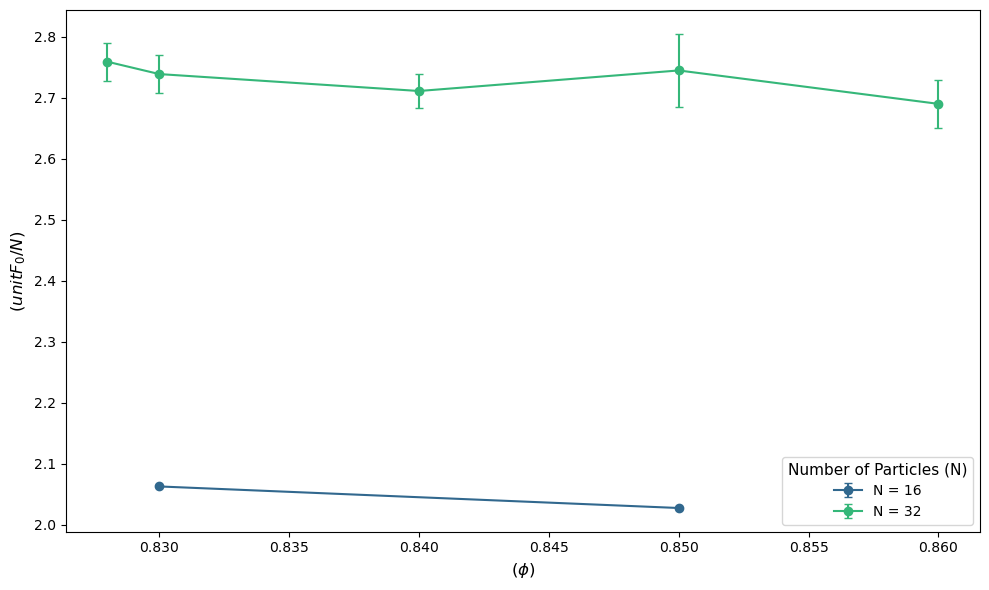

Plot generated successfully.


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np # Import numpy for checking division by zero
import os # To check if file exists

# --- Configuration ---
INPUT_CSV_FILE = 'volume_run_data/consolidated_mbar_data.csv'
# --- End Configuration ---

def plot_average_f0_per_particle(csv_filepath):
    """
    Loads data from the CSV, calculates average F0 per particle,
    and generates a plot.

    Args:
        csv_filepath (str): Path to the input CSV file.
    """
    # --- Step 1: Load Data ---
    if not os.path.exists(csv_filepath):
        print(f"Error: Input CSV file not found at '{csv_filepath}'")
        print("Please ensure the data consolidation script ran successfully and")
        print("this script is executed in the correct directory.")
        return

    try:
        df = pd.read_csv(csv_filepath)
        print(f"Successfully loaded data from '{csv_filepath}'.")
        print(f"Initial rows: {len(df)}")
    except Exception as e:
        print(f"Error loading CSV file '{csv_filepath}': {e}")
        return

    # --- Step 2: Data Cleaning and Preparation ---
    # Drop rows where essential data is missing
    initial_rows = len(df)
    df.dropna(subset=['unit_box_F0', 'n_particles', 'packing_fraction'], inplace=True)
    rows_after_na = len(df)
    if initial_rows > rows_after_na:
        print(f"Dropped {initial_rows - rows_after_na} rows due to missing values in key columns.")

    # Check for and handle potential division by zero or invalid n_particles
    if (df['n_particles'] <= 0).any():
        print("Warning: Found rows with n_particles <= 0. These rows will be excluded.")
        df = df[df['n_particles'] > 0].copy() # Use .copy() to avoid SettingWithCopyWarning

    if df.empty:
        print("No valid data remaining after cleaning. Cannot generate plot.")
        return

    # --- Step 3: Calculate F0 per particle ---
    # Calculate the quantity of interest: unit_box_F0 / N
    df['F0_per_particle'] = df['unit_box_F0'] / df['n_particles']
    print("Calculated 'F0_per_particle'.")

    # --- Step 4: Calculate Ensemble Averages ---
    # Group by n_particles and packing_fraction, then calculate mean and std dev
    # std() calculates the sample standard deviation (ddof=1 by default)
    try:
        avg_data = df.groupby(['n_particles', 'packing_fraction'])['F0_per_particle'].agg(['mean', 'std']).reset_index()
        # Rename columns for clarity
        avg_data.rename(columns={'mean': 'avg_F0_per_particle', 'std': 'std_F0_per_particle'}, inplace=True)
        # Fill NaN in std dev (happens for groups with only one data point) with 0 for plotting
        avg_data['std_F0_per_particle'].fillna(0, inplace=True)
        print("Calculated average and standard deviation for each group.")
        # print("\nAggregated Data Head:")
        # print(avg_data.head())

    except Exception as e:
        print(f"Error during grouping and aggregation: {e}")
        return

    if avg_data.empty:
        print("No data available after grouping. Cannot generate plot.")
        return

    # --- Step 5: Plotting ---
    print("Generating plot...")
    #plt.style.use('seaborn-v0_8-whitegrid') # Use a clean seaborn style
    plt.figure(figsize=(10, 6)) # Set figure size

    # Create the line plot using seaborn
    # 'hue' differentiates lines by color based on n_particles
    # 'style' differentiates lines by marker/linestyle based on n_particles
    # 'markers' adds markers to the points
    # 'errorbar' uses the 'std_F0_per_particle' column for error bars
    try:
        # Plotting requires mapping the std dev column explicitly if not using seaborn's built-in CI
        # One way is to loop and use plt.errorbar, or use seaborn and plot std dev manually if needed.
        # Let's try looping for explicit std dev bars.

        unique_n_particles = sorted(avg_data['n_particles'].unique())
        palette = sns.color_palette("viridis", n_colors=len(unique_n_particles)) # Color palette

        for i, n_part in enumerate(unique_n_particles):
            subset = avg_data[avg_data['n_particles'] == n_part].sort_values('packing_fraction')
            plt.errorbar(
                subset['packing_fraction'],
                subset['avg_F0_per_particle'],
                yerr=subset['std_F0_per_particle'],
                label=f'N = {n_part}',
                marker='o', # Add markers
                linestyle='-', # Use solid lines
                capsize=3, # Add caps to error bars
                color=palette[i] # Assign color from palette
            )

        # Add labels and title
        plt.xlabel("($\phi$)", fontsize=12)
        plt.ylabel("($unit F_0 / N$)", fontsize=12)
        plt.title("", fontsize=14)

        # Add legend
        plt.legend(title="Number of Particles (N)", title_fontsize='11', fontsize='10', loc='best')

        # Improve layout and display plot
        plt.tight_layout()
        plt.show()
        print("Plot generated successfully.")

    except Exception as e:
        print(f"Error during plotting: {e}")


# --- Main Execution ---
if __name__ == "__main__":
    plot_average_f0_per_particle(INPUT_CSV_FILE)

